In [1]:
#< START_SOLUTION 1 >

import matplotlib.pyplot as plt 
import numpy as np 

from skimage.color import rgb2gray
from skimage.filters import gaussian
from skimage.filters import sobel
from skimage.graph import shortest_path 
import skimage.io as io 
from skimage.transform import warp_polar 


im_fundus = io.imread("data/fundus.png",as_gray=True)

def shortest_path_left_right(im: np.array) -> np.array:     
    accumulator_image = np.zeros_like(im)
    backtracking_image = np.zeros_like(im).astype(int)
    accumulator_image[:, 0] = im[:, 0]
    for col in range(1, accumulator_image.shape[1]): #left to right, first row already initialized
            for row in range(accumulator_image.shape[0]):
                r_min = max(0, row - 1) #handle borders
                r_max = min(accumulator_image.shape[0] - 1, row + 1) #handle borders
                search_area = accumulator_image[r_min : r_max + 1, col - 1] # available rows: [row, row+1] or [row-1, row, row+1] or [row-1, row]
                min_idx_relative = np.argmin(search_area)
                best_row = r_min + min_idx_relative
                accumulator_image[row, col] = im[row, col] + accumulator_image[best_row, col-1]
                backtracking_image[row, col] = best_row
    return accumulator_image, backtracking_image 

A, T = shortest_path_left_right(im_fundus)


#< END_SOLUTION 1 >


In [2]:
#< START_SOLUTION 2 >

def backtrace_path(A, T):
    row_tmp = np.argmin(A[:, -1])
    start_col = A.shape[1] - 1                
    path_x, path_y = [], []
    for col in range(start_col, -1, -1):
        path_x.append(col)
        path_y.append(row_tmp)
        row_tmp = T[row_tmp, col]                            
    return path_x, path_y 

x, y = backtrace_path(A,T)

#< END_SOLUTION 2 >

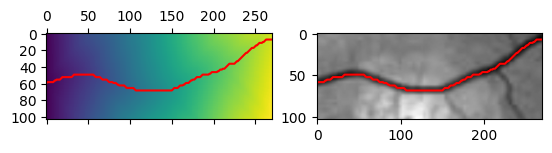

In [3]:
#< START_SOLUTION 3 >
def plot_results(im,A,x,y):
    fig, ax = plt.subplots(1,2)
    ax[0].matshow(A)
    ax[0].plot(x,y,color="red")
    
    ax[1].imshow(im,cmap="gray")
    ax[1].plot(x,y,color="red")
    
    plt.show()

plot_results(im_fundus,A,x,y)
#< END_SOLUTION 3 >

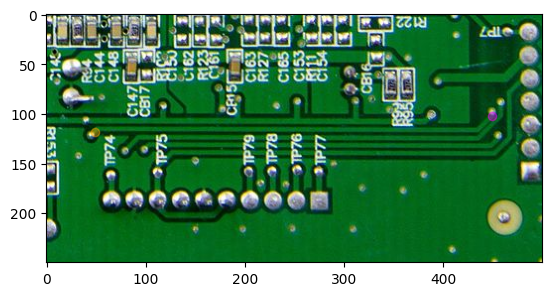

In [4]:
#< START_SOLUTION 4 >
im = io.imread("data/pcb.jpeg",)
crop_bounds = [[1150,1400],[1350,1850]]
im_crop = im[crop_bounds[0][0]:crop_bounds[0][1],crop_bounds[1][0]:crop_bounds[1][1]]

start_coords = [118,49]
end_coords = [102,449] #what we actually want
plt.imshow(im_crop)
plt.scatter(start_coords[1],start_coords[0], color = "orange", alpha=0.4)
plt.scatter(end_coords[1],end_coords[0], color = "magenta", alpha = 0.4)
plt.show()

#< END_SOLUTION 4 >

In [5]:
#< START_SOLUTION 5 >
"""
we want it to be the reverse image because then the "bright" green tracks
give us a low cost, which allows us to check the connectivity along the path
"""

im_crop = rgb2gray(im_crop)
im_crop_r = 1.0-im_crop


#< END_SOLUTION 5 >

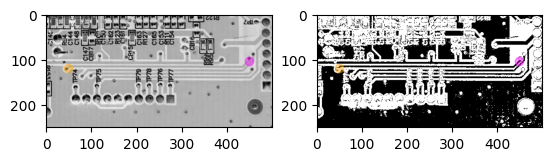

In [6]:
#< START_SOLUTION 6 >
fig, ax = plt.subplots(1,2)
ax[0].imshow(im_crop_r,cmap="gray")
ax[0].scatter(start_coords[1],start_coords[0], color="orange", alpha=0.4)
ax[0].scatter(end_coords[1],end_coords[0], color = "magenta", alpha = 0.4)


im_crop_r[(im_crop_r<0.60) | (im_crop_r>0.71)] = 1.0 
im_crop_r[(im_crop_r>=0.60) & (im_crop_r<=0.71)] = 0.0 

ax[1].imshow(im_crop_r,cmap="gray")
ax[1].scatter(start_coords[1],start_coords[0], color="orange", alpha=0.4)
ax[1].scatter(end_coords[1],end_coords[0], color = "magenta", alpha = 0.4)

plt.show()
#< END_SOLUTION 6 >

#### Exercise 7



Minimal found cost: 0.0


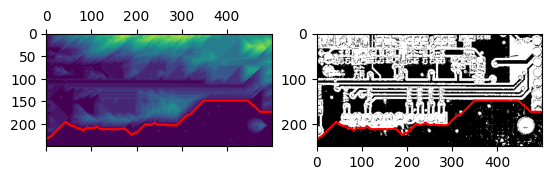

In [7]:
#< START_SOLUTION 7 >
A, T = shortest_path_left_right(im_crop_r)
x,y = backtrace_path(A,T)
print(f"Minimal found cost: {np.min(A[:,0])}")
plot_results(im_crop_r,A,x,y)
#The path makes a lot of sense, and the cost is indeed minimal as it is 0. There are probably multiple paths which achieve this, so the solution may not be unique. 
#< END_SOLUTION 7 >


#< START_SOLUTION 8 >

The accumulator image at the index of the end-point already holds all information we need for the cost. For extracting the path, we need to change the way we use the backtracking image for finding the path; instead of going from the right-most edge, we go from the end-coords. This is most easily done by extending the backtrace_path function, as done below:  


Found cost: 3.0


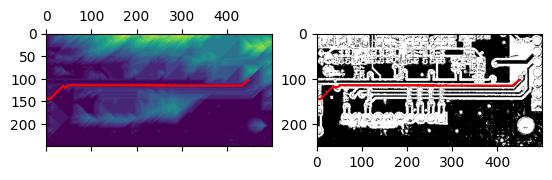

In [8]:
def backtrace_path(A, T, end_point = None):
    if end_point is None: 
        row_tmp = np.argmin(A[:, -1])
        start_col = A.shape[1] - 1
    else:
        row_tmp = end_point[0]
        start_col = end_point[1]

    print(f"Found cost: {A[row_tmp,start_col]}")

    path_x, path_y = [], []
    for col in range(start_col, -1, -1):
        path_x.append(col)
        path_y.append(row_tmp)
        row_tmp = T[row_tmp, col]                            
    return path_x, path_y 
x, y = backtrace_path(A,T, end_point=end_coords)
plot_results(im_crop_r,A,x,y)


#< END_SOLUTION 8 >

Found cost: 0.0
0.0


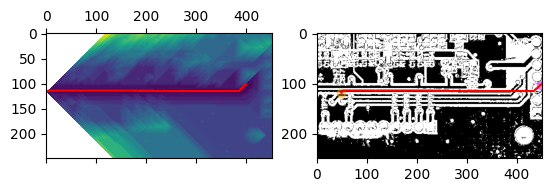

In [9]:
#< START_SOLUTION 9 >
h_, w_ = im_crop_r.shape
im_crop_r_start = im_crop_r[:,start_coords[1]:]
start_coords[1] = start_coords[1]-(w_-im_crop_r_start.shape[1])
end_coords[1] = end_coords[1]-(w_-im_crop_r_start.shape[1])


def shortest_path_left_right(im: np.array, start_point: list = None) -> np.array: 
    accumulator_image = np.zeros_like(im)
    backtracking_image = np.zeros_like(im).astype(int)
    """Add the following 5 lines"""
    if start_point:
            accumulator_image[:, 0] = np.inf # High cost -> enforce the path to go through start point 
            accumulator_image[start_point[0], 0] = im[start_point[0], 0] #keep intensity for start_point 
    else:
        accumulator_image[:, 0] = im[:, 0]
    for col in range(1, accumulator_image.shape[1]): #left to right, first row already initialized
            for row in range(accumulator_image.shape[0]):
                r_min = max(0, row - 1) #handle borders
                r_max = min(accumulator_image.shape[0] - 1, row + 1) #handle borders
                search_area = accumulator_image[r_min : r_max + 1, col - 1] # available rows: [row, row+1] or [row-1, row, row+1] or [row-1, row]
                min_idx_relative = np.argmin(search_area)
                best_row = r_min + min_idx_relative
                accumulator_image[row, col] = im[row, col] + accumulator_image[best_row, col-1]
                backtracking_image[row, col] = best_row
    return accumulator_image, backtracking_image 


A, T = shortest_path_left_right(im_crop_r_start, start_point=start_coords)
x,y = backtrace_path(A,T,end_point=end_coords)

print(A[end_coords[0],end_coords[1]])
fig, ax = plt.subplots(1,2)
ax[0].matshow(A)
ax[0].plot(x,y,color="red")
    
x = [x_+(w_-im_crop_r_start.shape[1]) for x_ in x]
y = [y_+(h_-im_crop_r_start.shape[0]) for y_ in y]

ax[1].imshow(im_crop_r_start,cmap="gray")
ax[1].plot(x,y,color="red")
ax[1].scatter(start_coords[1]+w_-im_crop_r_start.shape[1],start_coords[0], color="orange", alpha=0.4)
ax[1].scatter(end_coords[1]+w_-im_crop_r_start.shape[1],end_coords[0], color = "magenta", alpha = 0.4)

plt.show()

#< END_SOLUTION 9 >


0.0


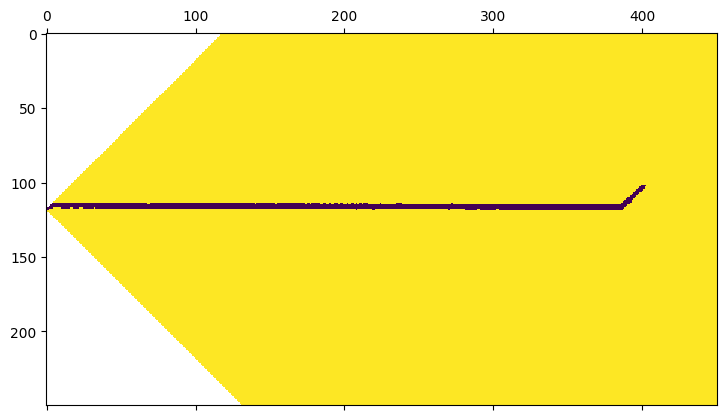

In [10]:
#< START_SOLUTION 10 >
print(A[end_coords[0],end_coords[1]]) #if this is larger than zero there is a defect present
plt.matshow(A,vmin=0.0,vmax=1) #the complete trace of electrical connectivity from point A
#< END_SOLUTION 10 >

# Exercise 11: Seam carving

Iteration 0: New width is 499
Iteration 50: New width is 449
Iteration 100: New width is 399
Iteration 150: New width is 349
Iteration 200: New width is 299


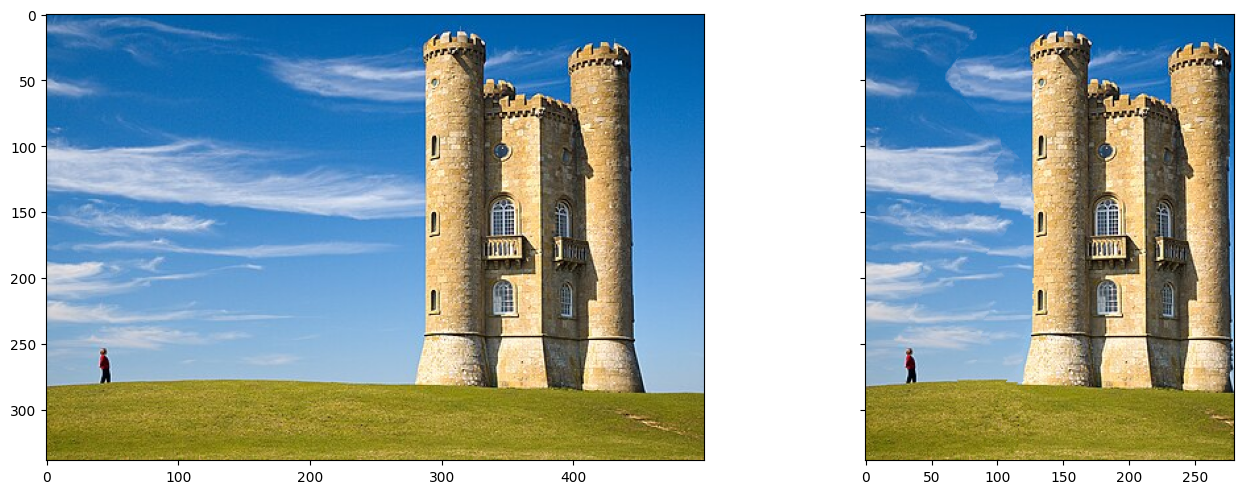

In [11]:
#< START_SOLUTION 11 >


def cut_seam_column(image: np.ndarray, path_x: np.ndarray) -> np.ndarray:
    rows, cols, channels = image.shape
    mask = np.ones((rows, cols), dtype=bool) # Create a True mask with shape H x W   
    mask[np.arange(rows), path_x] = False # Set the seam pixels to False
    image = image[mask] #keep everything but the seam. Note: this flattens the array to shape (H*W-H) x N_channels
    image = image.reshape((rows, cols - 1, channels)) #reshape back 
    if channels and channels==1: 
        image = image.squeeze(-1)
    return image 

def vertical_seam_carve(image: np.array, N_iter: int = 300):
    for i in range(N_iter):
        im_blur = gaussian(image,sigma=0.5,channel_axis=-1)
        energy_map = sobel(im_blur[:,:,0].squeeze())+sobel(im_blur[:,:,1].squeeze())+sobel(im_blur[:,:,-1].squeeze())
        path, total_cost = shortest_path(energy_map, reach=1, axis=0)
        path_x = np.array(path)
        image = cut_seam_column(image,path_x)
        if i % 50 == 0:
            print(f"Iteration {i}: New width is {image.shape[1]}")
    return image


im = io.imread("data/seam_carving_small.jpeg")
out_im = vertical_seam_carve(image=im, N_iter=220)
fig, ax = plt.subplots(1,2,sharey=True,figsize=(15,5))
ax[0].imshow(im)


ax[1].imshow(out_im)

plt.tight_layout()
plt.show()
#< END_SOLUTION 11 >


# Exercise 12

Iteration 0: New width is 499
Iteration 50: New width is 449
Iteration 100: New width is 399
Iteration 150: New width is 349
Iteration 200: New width is 299


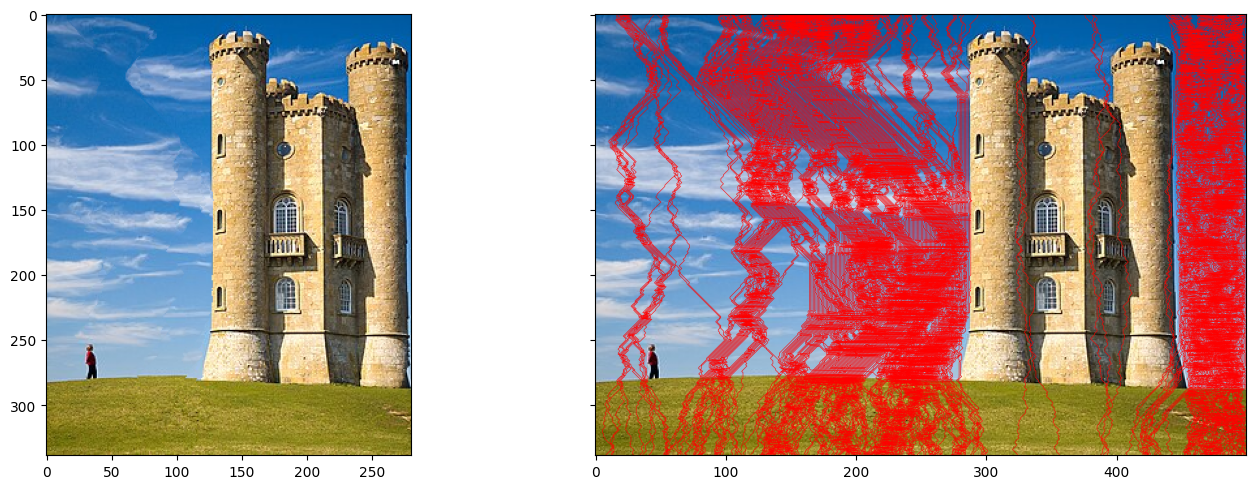

In [12]:
#< START_SOLUTION 12 >

def cut_seam_column(image: np.ndarray, path_x: np.ndarray) -> np.ndarray:
    if image.ndim>=3:
        rows, cols, channels = image.shape
    else:
        rows, cols = image.shape #also support the seam_map and grayscale images
        channels = 1  
    mask = np.ones((rows, cols), dtype=bool) # Create a True mask with shape H x W   
    mask[np.arange(rows), path_x] = False # Set the seam pixels to False
    image = image[mask] #keep everything but the seam. Note: this flattens the array to shape (H*W-H) x N_channels
    image = image.reshape((rows, cols - 1, channels)) #reshape back 
    if channels and channels==1: #case: grayscale or seam-map -> H x W-1
        image = image.squeeze(-1)
    return image 

def vertical_seam_carve_triplet(image: np.array, N_iter: int = 300):
    rows, cols, _ = image.shape
    all_original_seams = []
    col_map = np.tile(np.arange(cols), (rows, 1))
    for i in range(N_iter):
        im_blur = gaussian(image,sigma=0.5,channel_axis=-1)
        energy_map = sobel(im_blur[:,:,0].squeeze())+sobel(im_blur[:,:,1].squeeze())+sobel(im_blur[:,:,-1].squeeze())
        path, total_cost = shortest_path(energy_map, reach=1, axis=0)
        path_x = np.array(path)
        original_x = col_map[np.arange(rows), path_x]
        all_original_seams.append(original_x)
        image = cut_seam_column(image,path_x)
        col_map = cut_seam_column(col_map, path_x)
        if i % 50 == 0:
            print(f"Iteration {i}: New width is {image.shape[1]}")
    return image, all_original_seams

out_im, all_seams = vertical_seam_carve_triplet(image=im, N_iter=220)
fig, ax = plt.subplots(1,2,sharey=True,figsize=(15,5))
ax[0].imshow(out_im)
ax[1].imshow(im)
for seam in all_seams:
    ax[1].plot(seam, np.arange(im.shape[0]), color="red", alpha=0.8, linewidth=0.5)

plt.tight_layout()
#< END_SOLUTION 12 >


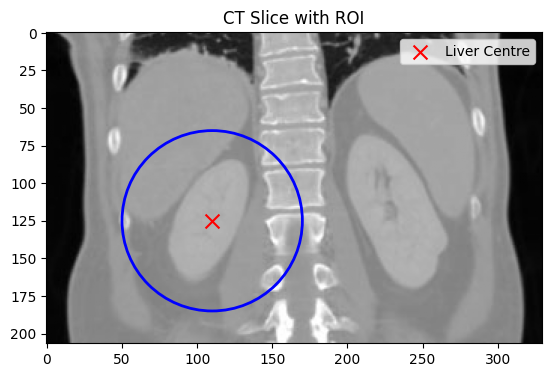

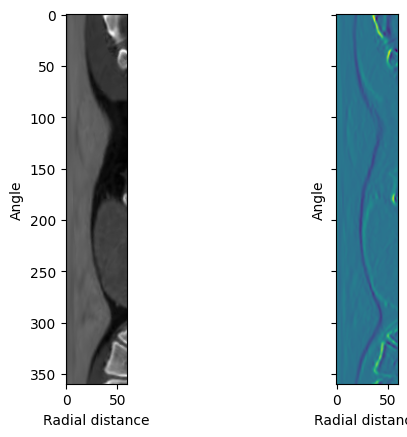

In [13]:
#< START_SOLUTION 13 >

im = io.imread("data/frontal_ct.png",as_gray=True)

fig, ax = plt.subplots(1,1)
ax.imshow(im,cmap="gray")
RADIUS = 60
spleen_centre = [125,110]
ax.scatter(spleen_centre[1], spleen_centre[0], s=100, c='red', marker='x', label='Liver Centre')
roi = plt.Circle((spleen_centre[1], spleen_centre[0]), RADIUS, color='blue', fill=False, linewidth=2)
ax.add_patch(roi)
ax.legend()
ax.set_title("CT Slice with ROI")
plt.show()

resampled = warp_polar(im, center=spleen_centre, radius=RADIUS, scaling='linear')

fig, ax = plt.subplots(1,2,sharey=True)
ax[0].imshow(resampled, cmap='gray') # No vmin/vmax needed now as it's 0-1



gradient_im = sobel(resampled, axis=1)

ax[1].imshow(gradient_im)
ax[0].set_xlabel("Radial distance")
ax[0].set_ylabel("Angle")
ax[1].set_xlabel("Radial distance")
ax[1].set_ylabel("Angle")

plt.show()
#< END_SOLUTION 13 >


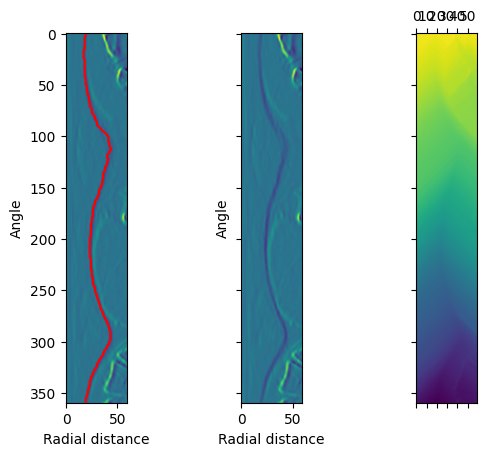

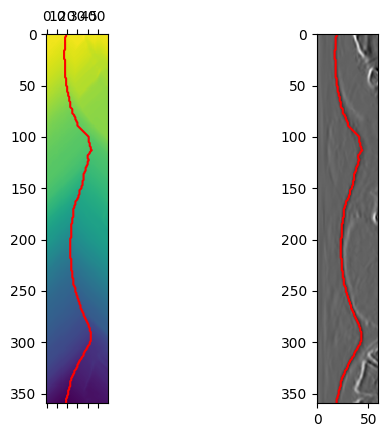

In [14]:
#< START_SOLUTION 14 >

def minimal_costing_path(im: np.array, direction: str, start_point: list = None, end_point: list = None) -> np.array: 
    horizontal = True if direction.lower()=="horizontal" else False 
    vertical = True if direction.lower()=="vertical" else False 
    

    accumulator_image = np.zeros_like(im)
    backtracking_image = np.zeros_like(im).astype(int)
    path_x = []
    path_y = []
    if vertical:
        accumulator_image[0,:] = im[0,:]

        for row in range(1, accumulator_image.shape[0]): 
            for col in range(accumulator_image.shape[1]):
                c_min = max(0, col-1)
                c_max = min(accumulator_image.shape[1]-1,col+1)
                search_area = accumulator_image[row-1,c_min:c_max+1]
                min_idx_relative = np.argmin(search_area)
                best_col = c_min+min_idx_relative
                accumulator_image[row,col] = im[row,col]+accumulator_image[row-1,best_col]
                backtracking_image[row,col] = best_col
        #backtracking 
        if end_point is None: 
            col_tmp = np.argmin(accumulator_image[-1, :])
            start_row = accumulator_image.shape[0] - 1
        
        else:
            start_row = end_point[0]
            col_tmp = end_point[1]
                
        # Trace back to row 0
        for row in range(start_row, -1, -1):
            path_x.append(col_tmp)
            path_y.append(row)
            col_tmp = backtracking_image[row, col_tmp]        

    elif horizontal: 
            if start_point:
                accumulator_image[:, 0] = np.inf # High cost
                accumulator_image[start_point[0], 0] = im[start_point[0], 0]
        
            else:
                accumulator_image[:, 0] = im[:, 0]
            for col in range(1, accumulator_image.shape[1]):
                    for row in range(accumulator_image.shape[0]):
                        #search radius
                        r_min = max(0, row - 1)
                        r_max = min(accumulator_image.shape[0] - 1, row + 1)
                        search_area = accumulator_image[r_min : r_max + 1, col - 1] # available rows: [row-1, row, row+1]
                        min_idx_relative = np.argmin(search_area)
                        best_row = r_min + min_idx_relative
                        accumulator_image[row, col] = im[row, col] + accumulator_image[best_row, col-1]
                        backtracking_image[row, col] = best_row
            # Backtracking
            if end_point is None: 
                row_tmp = np.argmin(accumulator_image[:, -1])
                start_col = accumulator_image.shape[1] - 1
            else:
                row_tmp = end_point[0]
                start_col = end_point[1]
                    
            # Trace back to column 0
            for col in range(start_col, -1, -1):
                path_x.append(col)
                path_y.append(row_tmp)
                row_tmp = backtracking_image[row_tmp, col]                        
        
    return accumulator_image, backtracking_image, path_x, path_y 



A, T, path_x, path_y = minimal_costing_path(gradient_im,direction="vertical")
fig, ax = plt.subplots(1,3,sharey=True)
ax[0].imshow(gradient_im)
ax[0].plot(np.array(path_x),np.array(path_y),color="red")
ax[1].imshow(gradient_im)
ax[2].matshow(A)
ax[0].set_xlabel("Radial distance")
ax[0].set_ylabel("Angle")
ax[1].set_xlabel("Radial distance")
ax[1].set_ylabel("Angle")


plt.show()


def plot_results(im,A,x,y):
    fig, ax = plt.subplots(1,2)
    ax[0].matshow(A)
    ax[0].plot(x,y,color="red")
    
    ax[1].imshow(im,cmap="gray")
    ax[1].plot(x,y,color="red")
    
    plt.show()

plot_results(gradient_im,A,path_x,path_y)

#< END_SOLUTION 14 >

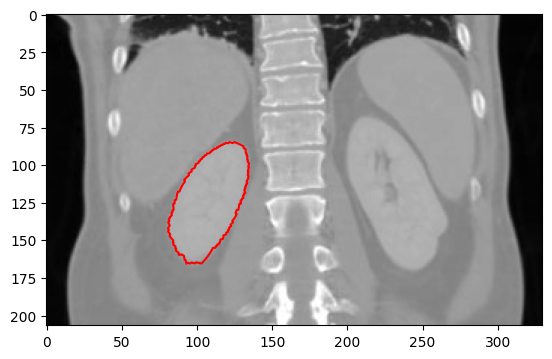

In [15]:


#< START_SOLUTION 15 >

col_p = np.array(path_x)
row_p = np.array(path_y)

thetas = 2*np.pi*row_p/len(row_p)
row_input = spleen_centre[0]+np.sin(thetas)*col_p
col_input = spleen_centre[1]+np.cos(thetas)*col_p

plt.imshow(im, cmap="gray")
plt.plot(col_input, row_input, color="red")

#< END_SOLUTION 15 >
